# Simulación de Monte Carlo (distribución triangular)

```
Modelo matemático
        │
        ▼
Identificar variables inciertas
        │
        ▼
Asignar distribuciones de probabilidad
        │
        ▼
Generar números aleatorios
        │
        ▼
Ejecutar miles de simulaciones
        │
        ▼
Analizar los resultados
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Modelo matemático

$$
\text{Ingresos} = \text{Precio} \times \text{Demanda}
$$

$$
\text{Margen} = \text{Ingresos} - \text{Costos fijos}
$$

In [2]:
precio = 6
demanda = 505_030
costos_fijos = 1_750_000

ingresos = precio * demanda
margen = ingresos - costos_fijos

print("Ingresos:", ingresos)
print("Margen:", margen)

Ingresos: 3030180
Margen: 1280180


## 2. Identificar variables inciertas

- **Precio** → fija (propia)
- **Demanda** → incierta (externa) → Low / Medium / High
- **Costos fijos** → fija (propia)
- **Ingresos y Margen** → se calculan

In [3]:
# Cada variable incierta se define con: low, mode (medium), high
# Puedes agregar más variables al diccionario si hace falta
variables_inciertas = {
    "demanda": {"low": 404_024, "mode": 505_030, "high": 606_036},
    # Ejemplo de una segunda variable incierta:
    # "costos_fijos": {"low": 1_500_000, "mode": 1_750_000, "high": 2_000_000},
}

print(variables_inciertas)

{'demanda': {'low': 404024, 'mode': 505030, 'high': 606036}}


## 3. Asignar distribuciones de probabilidad

Usamos la **distribución triangular** (mínimo, más probable, máximo).

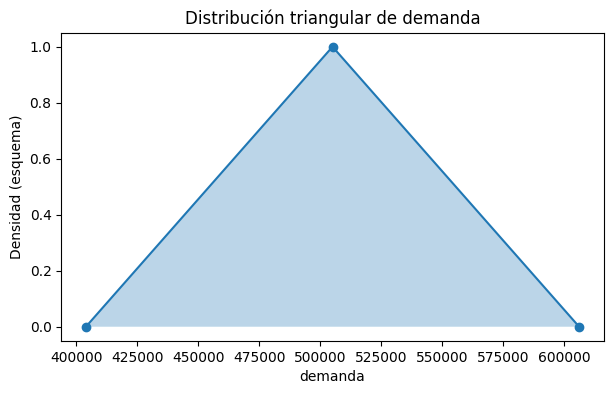

demanda → low: 404024 | mode: 505030 | high: 606036


In [4]:
for nombre, p in variables_inciertas.items():
    # Forma aproximada de la triangular: puntos (low, 0), (mode, pico), (high, 0)
    x = [p["low"], p["mode"], p["high"]]
    y = [0, 1, 0]  # solo para ver la forma

    plt.figure(figsize=(7, 4))
    plt.plot(x, y, marker="o")
    plt.fill_between(x, y, alpha=0.3)
    plt.title(f"Distribución triangular de {nombre}")
    plt.xlabel(nombre)
    plt.ylabel("Densidad (esquema)")
    plt.show()

    print(nombre, "→ low:", p["low"], "| mode:", p["mode"], "| high:", p["high"])

## 4. Generar números aleatorios

In [5]:
n = 10_000  # cantidad de simulaciones

muestras = {}
for nombre, p in variables_inciertas.items():
    muestras[nombre] = np.random.triangular(p["low"], p["mode"], p["high"], size=n)

# Ver las primeras muestras
for nombre, valores in muestras.items():
    print(nombre, "→ primeras 5:", valores[:5])

demanda → primeras 5: [491444.1087676  574324.07491345 532086.63039386 515542.11906796
 460446.25184025]


## 5. Ejecutar miles de simulaciones

In [6]:
# Si una variable es incierta usamos sus muestras; si no, el valor fijo
demanda_sim = muestras.get("demanda", np.full(n, demanda))
precio_sim = muestras.get("precio", np.full(n, precio))
costos_sim = muestras.get("costos_fijos", np.full(n, costos_fijos))

ingresos_sim = precio_sim * demanda_sim
margen_sim = ingresos_sim - costos_sim

print("Simulaciones:", n)
print("Primeros márgenes:", margen_sim[:5])

Simulaciones: 10000
Primeros márgenes: [1198664.6526056  1695944.44948072 1442519.78236317 1343252.71440774
 1012677.51104149]


## 6. Analizar los resultados

In [7]:
print("Media del margen:", margen_sim.mean())
print("Desviación estándar:", margen_sim.std())
print("Mínimo:", margen_sim.min())
print("Máximo:", margen_sim.max())
print()
print("Percentil 5%:", np.percentile(margen_sim, 5))
print("Percentil 50% (mediana):", np.percentile(margen_sim, 50))
print("Percentil 95%:", np.percentile(margen_sim, 95))
print()
print("Probabilidad de pérdida P(margen < 0):", (margen_sim < 0).mean())

Media del margen: 1275243.5027621712
Desviación estándar: 246090.7330457889
Mínimo: 677067.4256222332
Máximo: 1871815.1075318493

Percentil 5%: 866750.8487502245
Percentil 50% (mediana): 1275635.0306329706
Percentil 95%: 1689707.8769218093

Probabilidad de pérdida P(margen < 0): 0.0


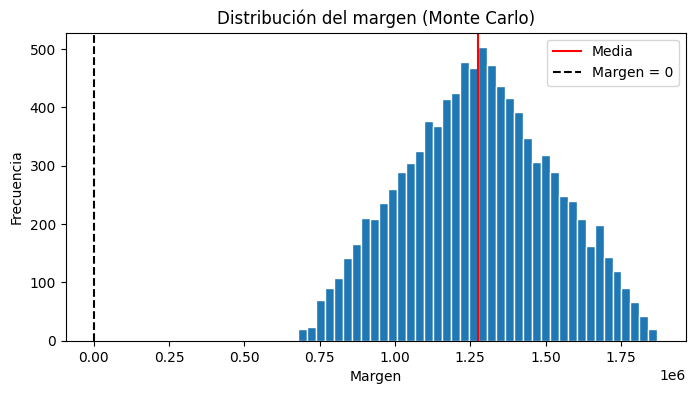

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(margen_sim, bins=40, edgecolor="white")
plt.axvline(margen_sim.mean(), color="red", label="Media")
plt.axvline(0, color="black", linestyle="--", label="Margen = 0")
plt.title("Distribución del margen (Monte Carlo)")
plt.xlabel("Margen")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

## 7. Gráficos extras de análisis

Además del histograma, conviene ver:
- cómo se relaciona cada variable incierta con el margen
- la correlación
- el impacto por rangos (efecto “marginal” aproximado)
- la probabilidad acumulada


### Relación: variable incierta vs margen

Cada punto es una simulación. Si la nube sube hacia la derecha, esa variable **aumenta** el margen.


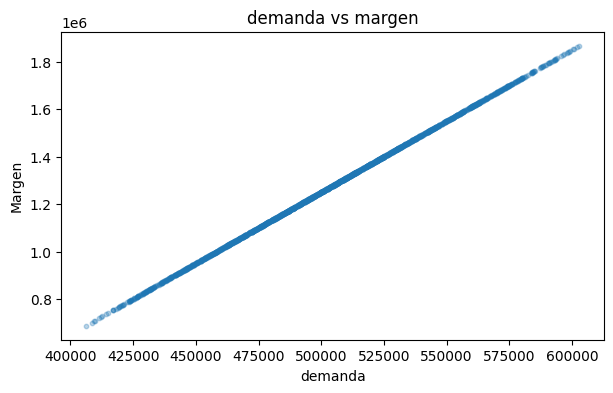

In [9]:
# Subconjunto para que el gráfico no se vea saturado
idx = np.random.choice(n, size=2000, replace=False)

for nombre, valores in muestras.items():
    plt.figure(figsize=(7, 4))
    plt.scatter(valores[idx], margen_sim[idx], alpha=0.3, s=10)
    plt.title(f"{nombre} vs margen")
    plt.xlabel(nombre)
    plt.ylabel("Margen")
    plt.show()


### Correlación con el margen

La correlación de Pearson mide qué tan lineal es la relación (−1 a 1).
Cerca de 1 = mucha relación positiva; cerca de 0 = poca relación lineal.


Correlación con el margen:
  demanda: 1.000


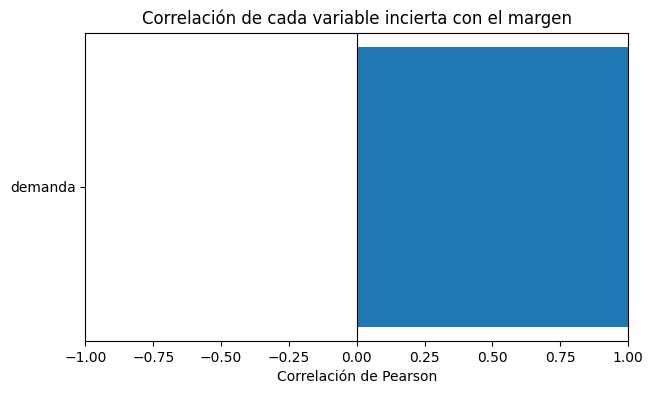

In [10]:
nombres = list(muestras.keys())
correlaciones = [np.corrcoef(muestras[nombre], margen_sim)[0, 1] for nombre in nombres]

print("Correlación con el margen:")
for nombre, corr in zip(nombres, correlaciones):
    print(f"  {nombre}: {corr:.3f}")

plt.figure(figsize=(7, 4))
plt.barh(nombres, correlaciones)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-1, 1)
plt.title("Correlación de cada variable incierta con el margen")
plt.xlabel("Correlación de Pearson")
plt.show()


### Impacto por rangos (efecto aproximado)

Partimos la demanda (u otra variable) en grupos bajos / medios / altos y comparamos el margen promedio.
Así se ve el impacto de pasar de un rango a otro.



Margen promedio según demanda:
  Bajo: 999,267
  Medio: 1,271,402
  Alto: 1,546,832
  Impacto Bajo → Medio: 272,135
  Impacto Medio → Alto: 275,430


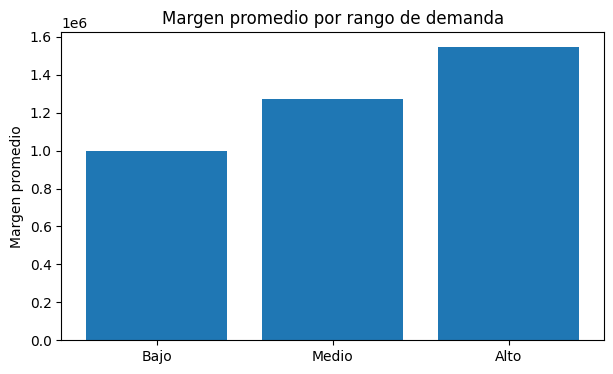

C:\Users\Light Force CR\AppData\Local\Temp\ipykernel_6520\257123359.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=orden)


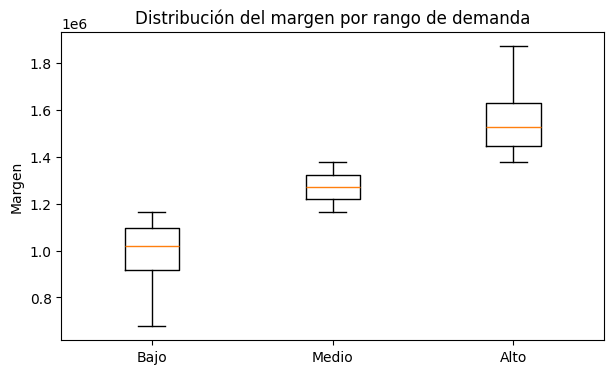

In [11]:
for nombre, valores in muestras.items():
    # Tres grupos: bajo, medio, alto (terciles)
    p33, p66 = np.percentile(valores, [33, 66])
    grupos = np.where(valores <= p33, "Bajo",
             np.where(valores <= p66, "Medio", "Alto"))

    orden = ["Bajo", "Medio", "Alto"]
    medias = [margen_sim[grupos == g].mean() for g in orden]

    print(f"\nMargen promedio según {nombre}:")
    for g, m in zip(orden, medias):
        print(f"  {g}: {m:,.0f}")

    # Impacto al pasar de Bajo → Medio y de Medio → Alto
    print(f"  Impacto Bajo → Medio: {medias[1] - medias[0]:,.0f}")
    print(f"  Impacto Medio → Alto: {medias[2] - medias[1]:,.0f}")

    plt.figure(figsize=(7, 4))
    plt.bar(orden, medias)
    plt.title(f"Margen promedio por rango de {nombre}")
    plt.ylabel("Margen promedio")
    plt.show()

    # Boxplot: distribución completa del margen en cada rango
    datos_box = [margen_sim[grupos == g] for g in orden]
    plt.figure(figsize=(7, 4))
    plt.boxplot(datos_box, labels=orden)
    plt.title(f"Distribución del margen por rango de {nombre}")
    plt.ylabel("Margen")
    plt.show()


### ¿Qué tan probable es cada nivel de margen %?

Leemos el gráfico así:

> “¿Qué % de las simulaciones quedó con un margen **menor o igual** a este valor?”

Ejemplo: si en el eje X marcas 40% y la curva está en 0.33, entonces  
**P(margen % ≤ 40%) ≈ 33%**.


Probabilidades del margen %:

  P(margen % ≤ 20%) = 0.0%
  P(margen % ≥ 20%) = 100.0%

  P(margen % ≤ 30%) = 0.7%
  P(margen % ≥ 30%) = 99.3%

  P(margen % ≤ 40%) = 33.5%
  P(margen % ≥ 40%) = 66.5%

  P(margen % ≤ 50%) = 97.7%
  P(margen % ≥ 50%) = 2.3%

  P(margen % ≤ 100%) = 100.0%
  P(margen % ≥ 100%) = 0.0%



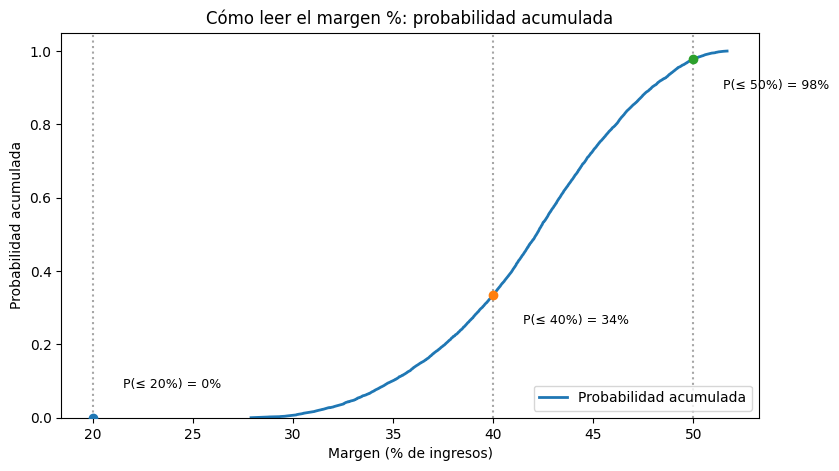

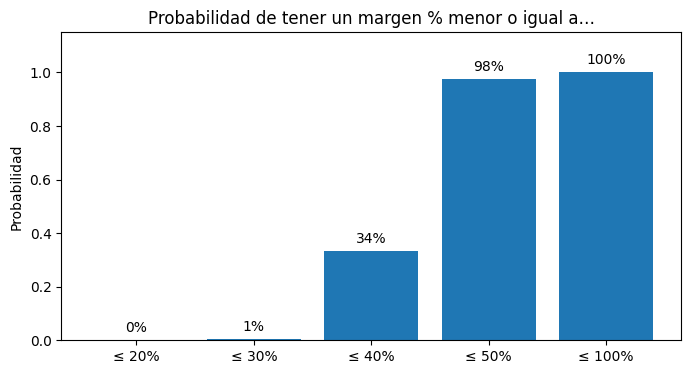

In [12]:
# Margen como % de los ingresos
margen_pct = margen_sim / ingresos_sim * 100

# Preguntas típicas (cámbialas si quieres otros umbrales)
umbrales = [20, 30, 40, 50, 100]

print("Probabilidades del margen %:\n")
for u in umbrales:
    p_menor_igual = (margen_pct <= u).mean()
    p_mayor_igual = (margen_pct >= u).mean()
    print(f"  P(margen % ≤ {u}%) = {p_menor_igual:.1%}")
    print(f"  P(margen % ≥ {u}%) = {p_mayor_igual:.1%}")
    print()

# Curva acumulada (muy fácil de interpretar)
margen_pct_ord = np.sort(margen_pct)
prob_acum_pct = np.arange(1, n + 1) / n

plt.figure(figsize=(9, 5))
plt.plot(margen_pct_ord, prob_acum_pct, linewidth=2, label="Probabilidad acumulada")

# Marcamos umbrales útiles
for u in [20, 40, 50]:
    p = (margen_pct <= u).mean()
    plt.axvline(u, color="gray", linestyle=":", alpha=0.7)
    plt.scatter([u], [p], zorder=5)
    plt.annotate(
        f"P(≤ {u}%) = {p:.0%}",
        xy=(u, p),
        xytext=(u + 1.5, p - 0.08 if p > 0.15 else p + 0.08),
        fontsize=9,
    )

plt.title("Cómo leer el margen %: probabilidad acumulada")
plt.xlabel("Margen (% de ingresos)")
plt.ylabel("Probabilidad acumulada")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

# Barras: resumen directo de las preguntas
etiquetas = [f"≤ {u}%" for u in umbrales]
valores = [(margen_pct <= u).mean() for u in umbrales]

plt.figure(figsize=(8, 4))
barras = plt.bar(etiquetas, valores)
plt.ylim(0, 1.15)
plt.ylabel("Probabilidad")
plt.title("Probabilidad de tener un margen % menor o igual a…")
for barra, v in zip(barras, valores):
    plt.text(barra.get_x() + barra.get_width() / 2, v + 0.03, f"{v:.0%}",
             ha="center", fontsize=10)
plt.show()


### Probabilidad acumulada del margen

Lee el eje Y como: “probabilidad de obtener un margen **menor o igual** a este valor”.


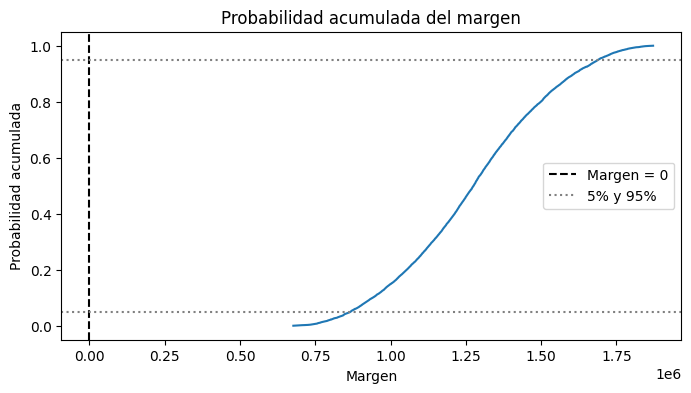

In [13]:
margen_ordenado = np.sort(margen_sim)
prob_acum = np.arange(1, n + 1) / n

plt.figure(figsize=(8, 4))
plt.plot(margen_ordenado, prob_acum)
plt.axvline(0, color="black", linestyle="--", label="Margen = 0")
plt.axhline(0.05, color="gray", linestyle=":", label="5% y 95%")
plt.axhline(0.95, color="gray", linestyle=":")
plt.title("Probabilidad acumulada del margen")
plt.xlabel("Margen")
plt.ylabel("Probabilidad acumulada")
plt.legend()
plt.show()
